14061
14061


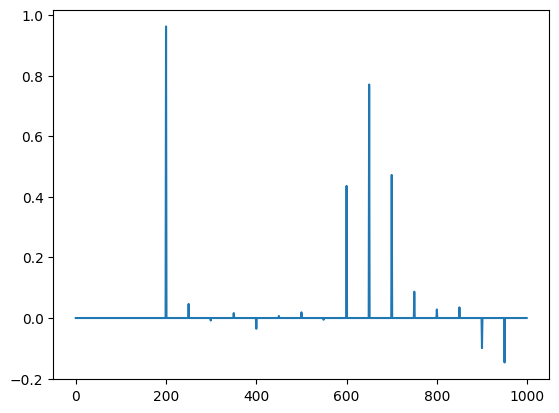

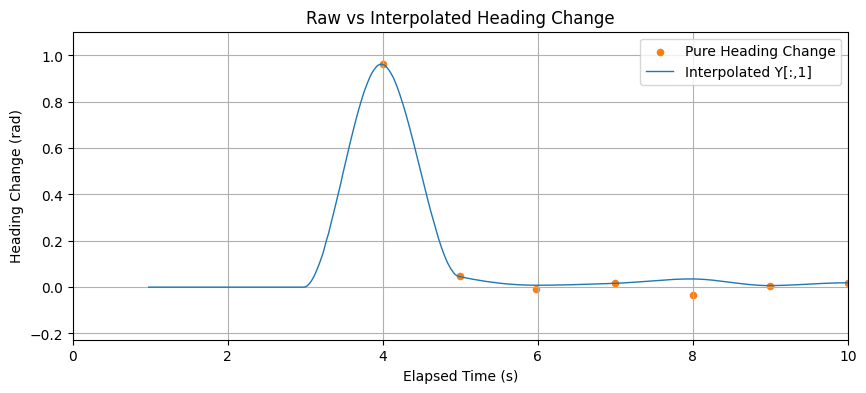

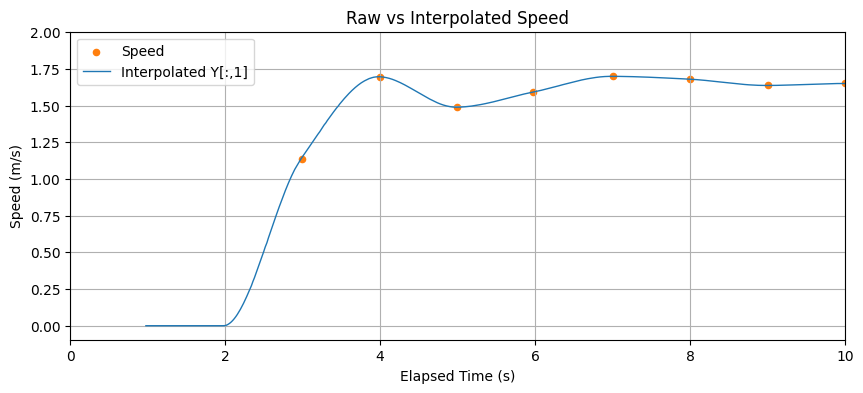

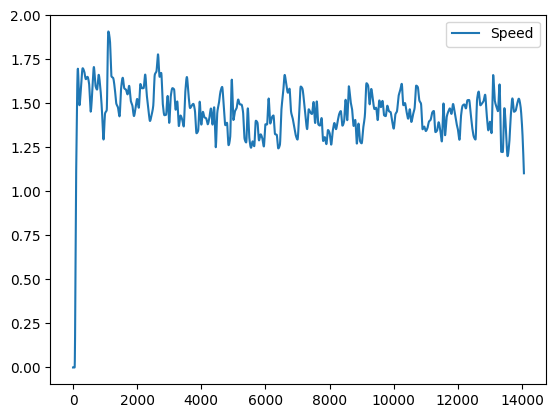

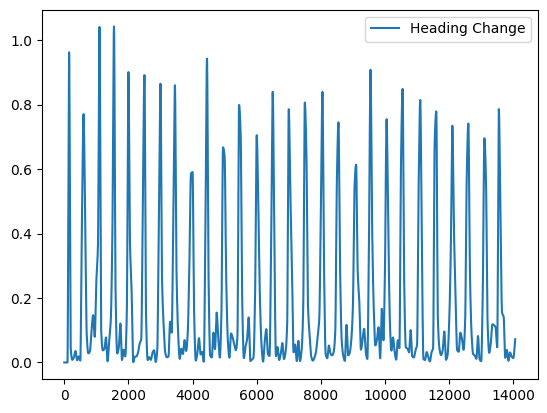

In [4]:
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import os
import time
import logging
from datetime import datetime
from pyproj import CRS, Transformer
from scipy.interpolate import PchipInterpolator, UnivariateSpline
from scipy.signal import savgol_filter
import math
from numpy.lib.stride_tricks import sliding_window_view

# 현재 main.py 파일의 디렉토리를 기준으로 프로젝트 루트 경로 설정
BASE_DIR = os.getcwd()

# 시드 값 고정
SEED = 1217  
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def main():
    # ============================================================
    # 1. 학습 데이터 로딩 및 전처리
    # ============================================================
    learn_data_paths = [
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_2.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking3.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking4.csv'),
        os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_01.csv'),
        #os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_02.csv'),
        #os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_03.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_01.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_02.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_03.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing2.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing3.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing4.csv'),
    ]

    df_list = []
    for path in learn_data_paths:
        if os.path.exists(path):
            # CSV 파일 로딩 및 전처리 (skiprows: 처음 100행 스킵)
            df = DataProcessor.load_and_preprocess_csv(path, skiprows=0)
            df_list.append(df)
        else:
            print(f"파일을 찾을 수 없습니다: {path}")

    # ============================================================
    # 2. 슬라이딩 윈도우 방식으로 X, Y 데이터 생성
    # ============================================================
    X_list, Y_list = [], []
    for df in df_list:
        X_sub, Y_sub = DataProcessor.make_XY_using_dataframe(df)
        X_list.append(X_sub)
        Y_list.append(Y_sub)

    if not X_list:
        print("학습 데이터를 불러오지 못했습니다.")
        return

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)

    df = df_list[0]
    t_full = df['Elapsed Time'].values
    window_size = 50
    stride = 1

    # 1) 원본 이벤트 시점 + 값
    t_hc = df.loc[df['Pure Heading Change'] != 0, 'Elapsed Time'].values
    hc   = df.loc[df['Pure Heading Change'] != 0, 'Pure Heading Change'].values
    t_speed = df.loc[df['Speed'] != 0, 'Elapsed Time'].values
    speed = df.loc[df['Speed'] != 0, 'Speed'].values


    plt.plot(df['Pure Heading Change'][:1000])
    plt.show()
    # 2) 보간 레이블 시점 + 값
    t_Y = t_full[window_size-1 :: stride]      # Y[:,1] 의 시간축
    Y_hc = Y[:,1]
    Y_speed = Y[:,0]

    plt.figure(figsize=(10,4))
    plt.xlim(0, 10)
    # 원본 이벤트 (산점도)
    plt.scatter(t_hc, hc,
                c='C1', s=20, marker='o',
                label='Pure Heading Change')

    # 보간 레이블 (라인)
    plt.plot(t_Y, Y_hc,
            c='C0', linewidth=1,
            label='Interpolated Y[:,1]')

     # 시간 범위 조절
    plt.xlabel('Elapsed Time (s)')
    plt.ylabel('Heading Change (rad)')
    plt.title('Raw vs Interpolated Heading Change')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(10,4))
    plt.xlim(0, 10)
    plt.scatter(t_speed, speed,
                c='C1', s=20, marker='o',
                label='Speed')
    
    plt.plot(t_Y, Y_speed,
            c='C0', linewidth=1,
            label='Interpolated Y[:,1]')
    
    plt.xlabel('Elapsed Time (s)')
    plt.ylabel('Speed (m/s)')
    plt.title('Raw vs Interpolated Speed')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.plot(Y[:, 0], label='Speed')
    plt.legend()
    plt.show()
    
    plt.plot(Y[:, 1], label='Heading Change')
    plt.legend()
    plt.show()
    
       
if __name__ == '__main__':
    main()
